# 02 — SQL and Exploratory Analysis

*Executed analytical companion to the validated production pipeline.*

## Objective

Explain the SQLite star schema and validated exploratory results using read-only database metadata, named SQL definitions, exported aggregates, and existing charts.

## Business Questions

- How is the analytical star schema organised and reconciled?
- What are the confirmed executive KPIs?
- How do sales vary over time, geography, product, and order value?
- Which interpretation caveats matter for decision-makers?

## Inputs

- `data/processed/retail_analytics.sqlite` opened read-only
- `sql/03_business_queries.sql` parsed with the reusable SQL runner
- `reports/sql_results/`, `reports/eda_tables/`, and `reports/eda_summary.json`
- Existing charts under `images/eda/`

## Methodology

Inspect database metadata and compact exported reports. Named analytical SQL is parsed, not reimplemented; million-row facts are never printed.

## Code

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "src" / "retail_analytics").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_rows", 12)
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

def load_json(relative_path):
    return json.loads((PROJECT_ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

import sqlite3
from retail_analytics.sql_runner import parse_named_queries

sql_model = load_json("reports/sql_model_summary.json")
eda_summary = load_json("reports/eda_summary.json")
manifest = load_json("reports/sql_query_manifest.json")
database_path = PROJECT_ROOT / "data" / "processed" / "retail_analytics.sqlite"

Project root: C:\Projects\Retail-Customer-Intelligence-Analytics
Python: 3.12.7


In [2]:
uri = f"file:{database_path.as_posix()}?mode=ro"
with sqlite3.connect(uri, uri=True) as connection:
    schema_objects = pd.read_sql_query(
        "SELECT name, type FROM sqlite_master "
        "WHERE type IN ('table', 'index') AND name NOT LIKE 'sqlite_%' "
        "ORDER BY type, name",
        connection,
    )
display(schema_objects)

table_counts = pd.DataFrame(
    [(name, rows) for name, rows in sql_model["table_counts"].items()],
    columns=["Star-schema table", "Rows"],
)
table_counts["Rows"] = table_counts["Rows"].map(lambda value: f"{value:,.0f}")
display(table_counts)
print("Foreign-key failures:", sql_model["foreign_key_failures"])

,name,type
0,idx_returns_customer,index
1,idx_returns_date,index
2,idx_returns_product,index
3,idx_sales_country,index
4,idx_sales_customer,index
...,...,...
10,dim_customer,table
11,dim_date,table
12,dim_product,table
13,fact_returns,table


,Star-schema table,Rows
0,dim_date,604
1,dim_product,"5,304"
2,dim_customer,"5,878"
3,dim_country,43
4,fact_sales,"1,007,913"
5,fact_returns,"22,497"
6,audit_exclusions,"2,626"


Foreign-key failures: 0


In [3]:
named_queries = parse_named_queries(PROJECT_ROOT / "sql" / "03_business_queries.sql")
query_catalogue = pd.DataFrame([
    {
        "Query": name,
        "Exported rows": manifest["queries"][name]["rows"],
        "Output columns": len(manifest["queries"][name]["columns"]),
    }
    for name, _ in named_queries
])
display(query_catalogue)

,Query,Exported rows,Output columns
0,executive_kpis,1,5
1,monthly_revenue_growth,25,4
2,country_performance,43,5
3,top_products,20,5
4,top_customers,20,7
5,repeat_customer_rate,1,3
6,product_returns,20,5
7,customer_revenue_deciles,10,4
8,outlier_profile,1,4


## Results

In [4]:
kpis = pd.read_csv(PROJECT_ROOT / "reports" / "sql_results" / "executive_kpis.csv").iloc[0]
kpi_table = pd.DataFrame([
    ("Completed-sales revenue", f"GBP {kpis.revenue_gbp:,.2f}"),
    ("Completed orders", f"{kpis.orders:,.0f}"),
    ("Identified customers", f"{kpis.identified_customers:,.0f}"),
    ("Average order value", f"GBP {kpis.average_order_value_gbp:,.2f}"),
    ("Revenue per identified customer", f"GBP {kpis.revenue_per_identified_customer_gbp:,.2f}"),
], columns=["Executive KPI", "Validated value"])
display(kpi_table)

monthly = pd.read_csv(PROJECT_ROOT / "reports" / "eda_tables" / "monthly_performance.csv")
monthly_view = monthly.tail(6)[
    ["year_month", "revenue_gbp", "orders", "average_order_value_gbp", "is_partial_period"]
].copy()
monthly_view["revenue_gbp"] = monthly_view["revenue_gbp"].map(lambda value: f"GBP {value:,.2f}")
monthly_view["average_order_value_gbp"] = monthly_view["average_order_value_gbp"].map(lambda value: f"GBP {value:,.2f}")
monthly_view["orders"] = monthly_view["orders"].map(lambda value: f"{value:,.0f}")
display(monthly_view)

,Executive KPI,Validated value
0,Completed-sales revenue,"GBP 20,476,260.45"
1,Completed orders,"40,077"
2,Identified customers,"5,878"
3,Average order value,GBP 510.92
4,Revenue per identified customer,"GBP 2,955.90"


,year_month,revenue_gbp,orders,average_order_value_gbp,is_partial_period
19,2011-07,"GBP 718,076.12","1,475",GBP 486.83,False
20,2011-08,"GBP 757,841.38","1,361",GBP 556.83,False
21,2011-09,"GBP 1,056,435.19","1,837",GBP 575.09,False
22,2011-10,"GBP 1,151,263.73","2,040",GBP 564.34,False
23,2011-11,"GBP 1,503,866.78","2,769",GBP 543.11,False
24,2011-12,"GBP 637,808.33",819,GBP 778.76,True


In [5]:
country = pd.read_csv(PROJECT_ROOT / "reports" / "eda_tables" / "country_performance.csv").head(8)
country_view = country[["country", "revenue_gbp", "orders", "revenue_share_pct"]].copy()
country_view["revenue_gbp"] = country_view["revenue_gbp"].map(lambda value: f"GBP {value:,.2f}")
country_view["orders"] = country_view["orders"].map(lambda value: f"{value:,.0f}")
country_view["revenue_share_pct"] = country_view["revenue_share_pct"].map(lambda value: f"{value:.2f}%")
display(country_view)

products = pd.read_csv(PROJECT_ROOT / "reports" / "eda_tables" / "product_performance.csv").head(8)
product_view = products[["stock_code", "description", "units_sold", "revenue_gbp", "revenue_share_pct"]].copy()
product_view["units_sold"] = product_view["units_sold"].map(lambda value: f"{value:,.0f}")
product_view["revenue_gbp"] = product_view["revenue_gbp"].map(lambda value: f"GBP {value:,.2f}")
product_view["revenue_share_pct"] = product_view["revenue_share_pct"].map(lambda value: f"{value:.2f}%")
display(product_view)

orders = pd.read_csv(PROJECT_ROOT / "reports" / "eda_tables" / "order_summary.csv", usecols=["order_value_gbp"])
quantiles = orders["order_value_gbp"].quantile([0.25, 0.50, 0.75, 0.90, 0.99])
display(pd.DataFrame({"Order-value percentile": ["25%", "50%", "75%", "90%", "99%"],
                      "Order value": [f"GBP {value:,.2f}" for value in quantiles]}))

,country,revenue_gbp,orders,revenue_share_pct
0,United Kingdom,"GBP 17,410,196.12","36,535",85.03%
1,EIRE,"GBP 658,767.31",626,3.22%
2,Netherlands,"GBP 554,038.09",228,2.71%
3,Germany,"GBP 425,019.71",789,2.08%
4,France,"GBP 350,456.09",622,1.71%
5,Australia,"GBP 169,283.46",95,0.83%
6,Spain,"GBP 108,332.49",154,0.53%
7,Switzerland,"GBP 100,685.59",93,0.49%


,stock_code,description,units_sold,revenue_gbp,revenue_share_pct
0,M,Manual,"9,629","GBP 339,226.24",1.66%
1,22423,REGENCY CAKESTAND 3 TIER,"26,478","GBP 330,590.32",1.61%
2,DOT,DOTCOM POSTAGE,"1,415","GBP 309,854.11",1.51%
3,85123A,CREAM HANGING HEART T-LIGHT HOLDER,"94,203","GBP 257,724.71",1.26%
4,85099B,JUMBO BAG RED RETROSPOT,"96,757","GBP 180,569.34",0.88%
5,23843,"PAPER CRAFT , LITTLE BIRDIE","80,995","GBP 168,469.60",0.82%
6,47566,PARTY BUNTING,"28,200","GBP 148,318.28",0.72%
7,84879,ASSORTED COLOUR BIRD ORNAMENT,"80,082","GBP 129,324.49",0.63%


,Order-value percentile,Order value
0,25%,GBP 149.75
1,50%,GBP 302.22
2,75%,GBP 493.40
3,90%,GBP 929.29
4,99%,"GBP 4,408.59"


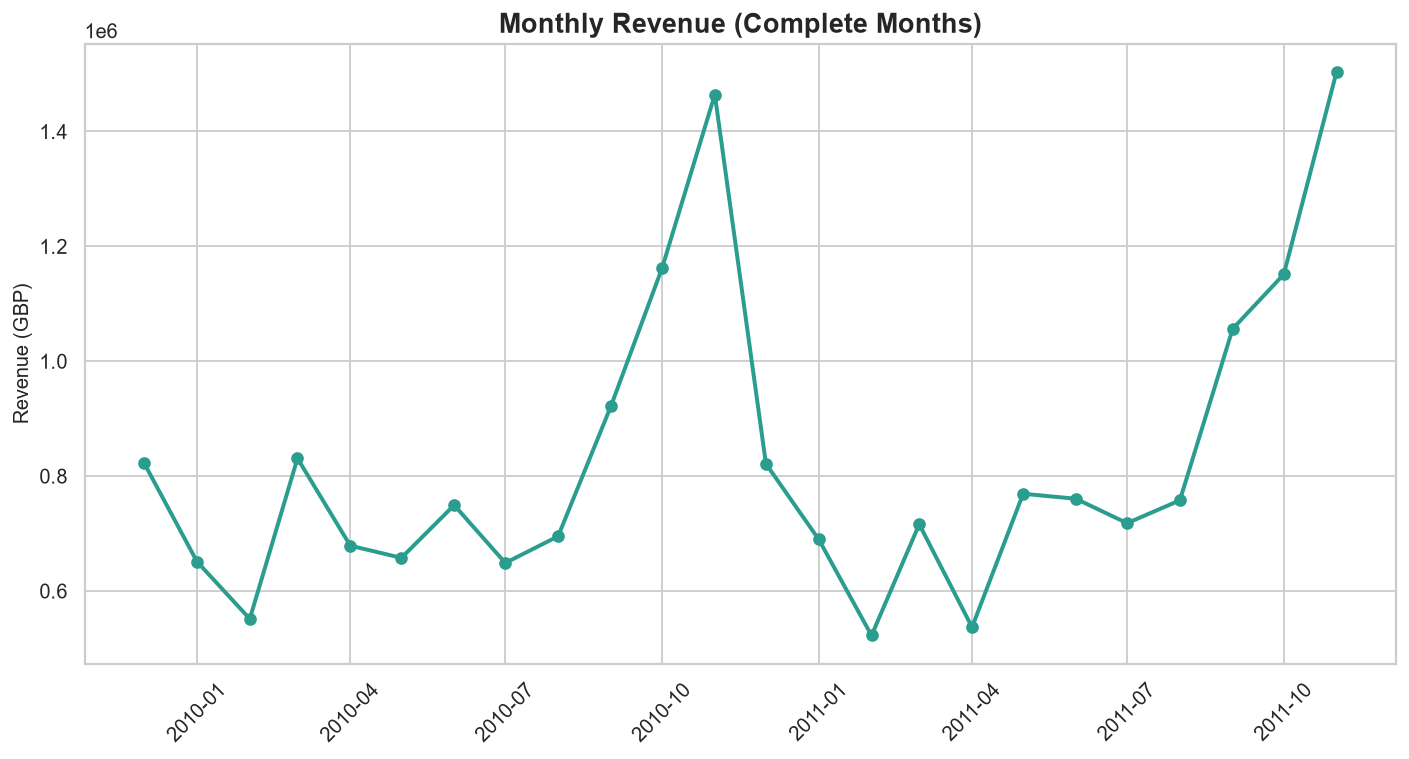

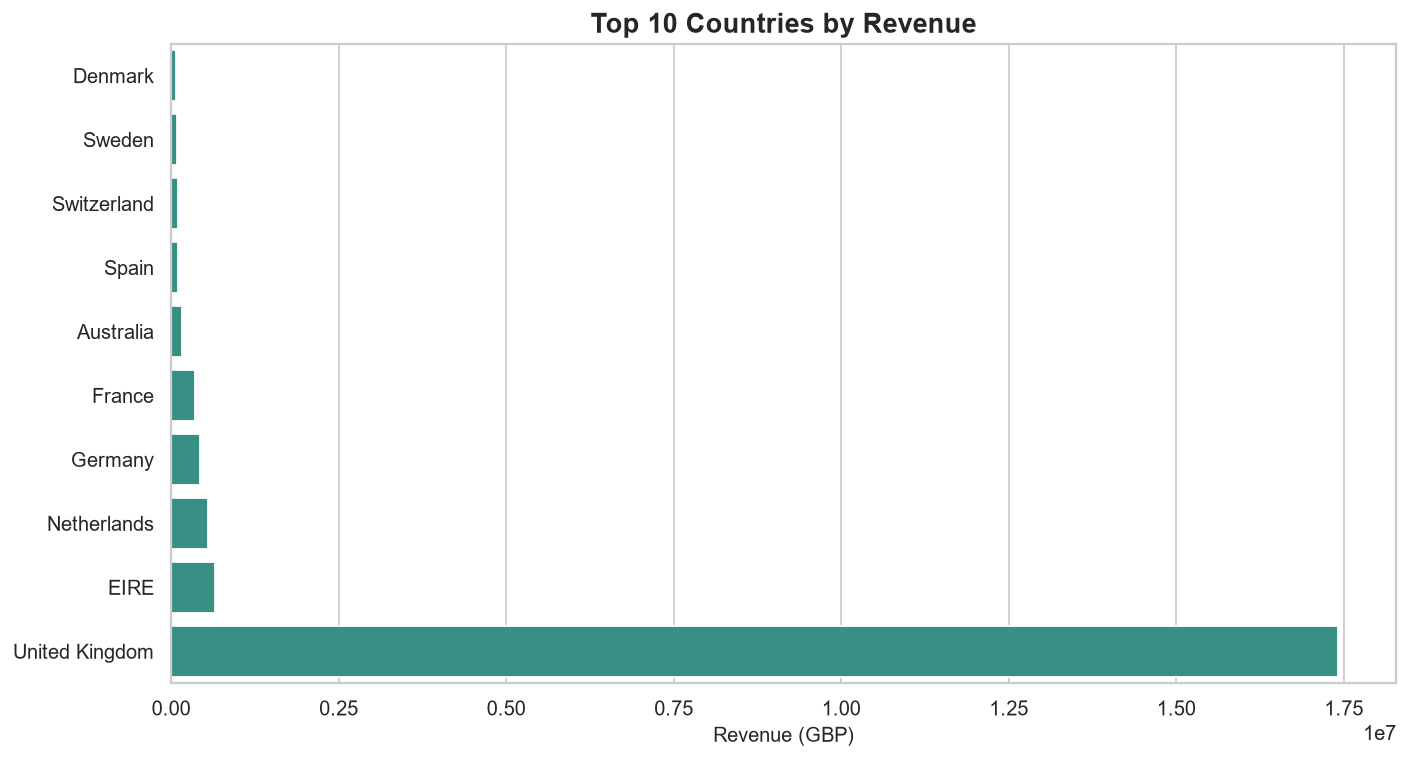

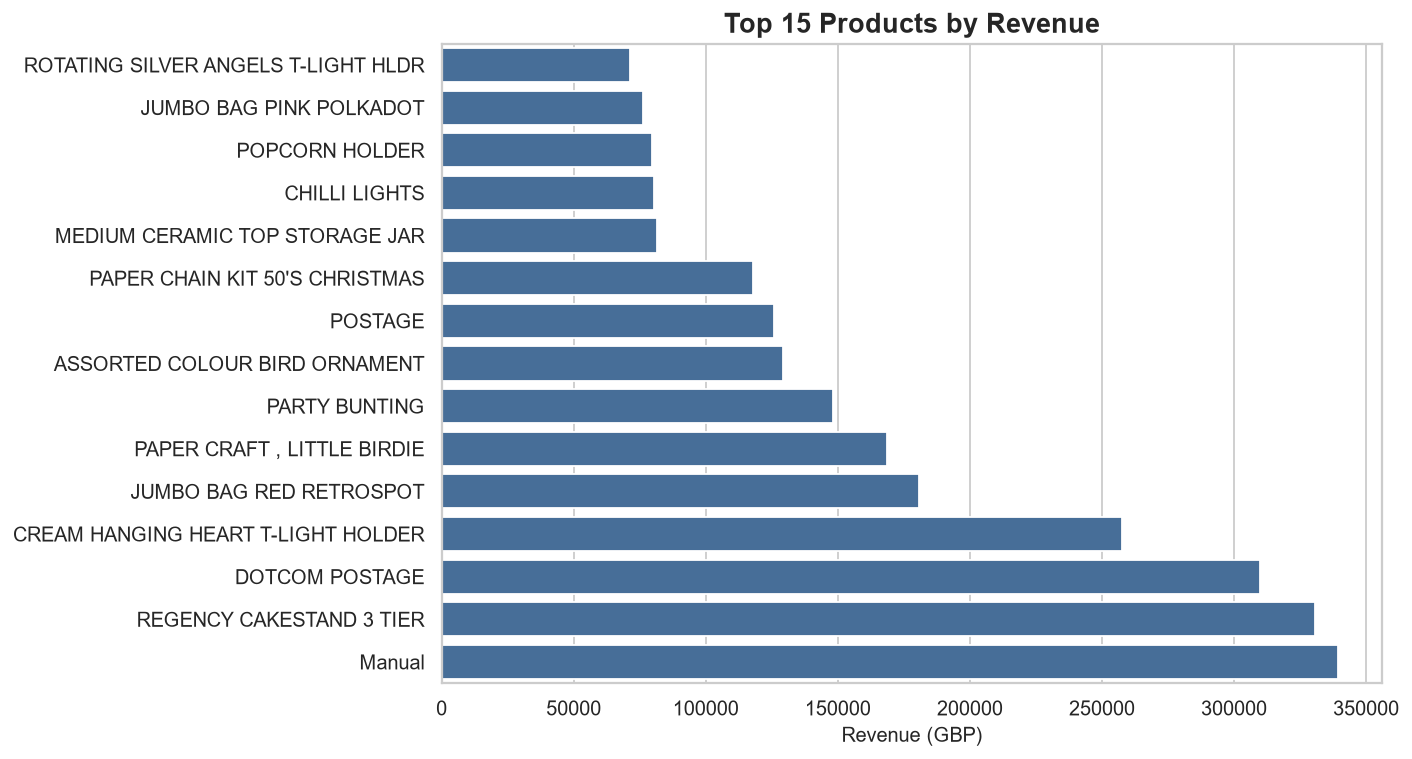

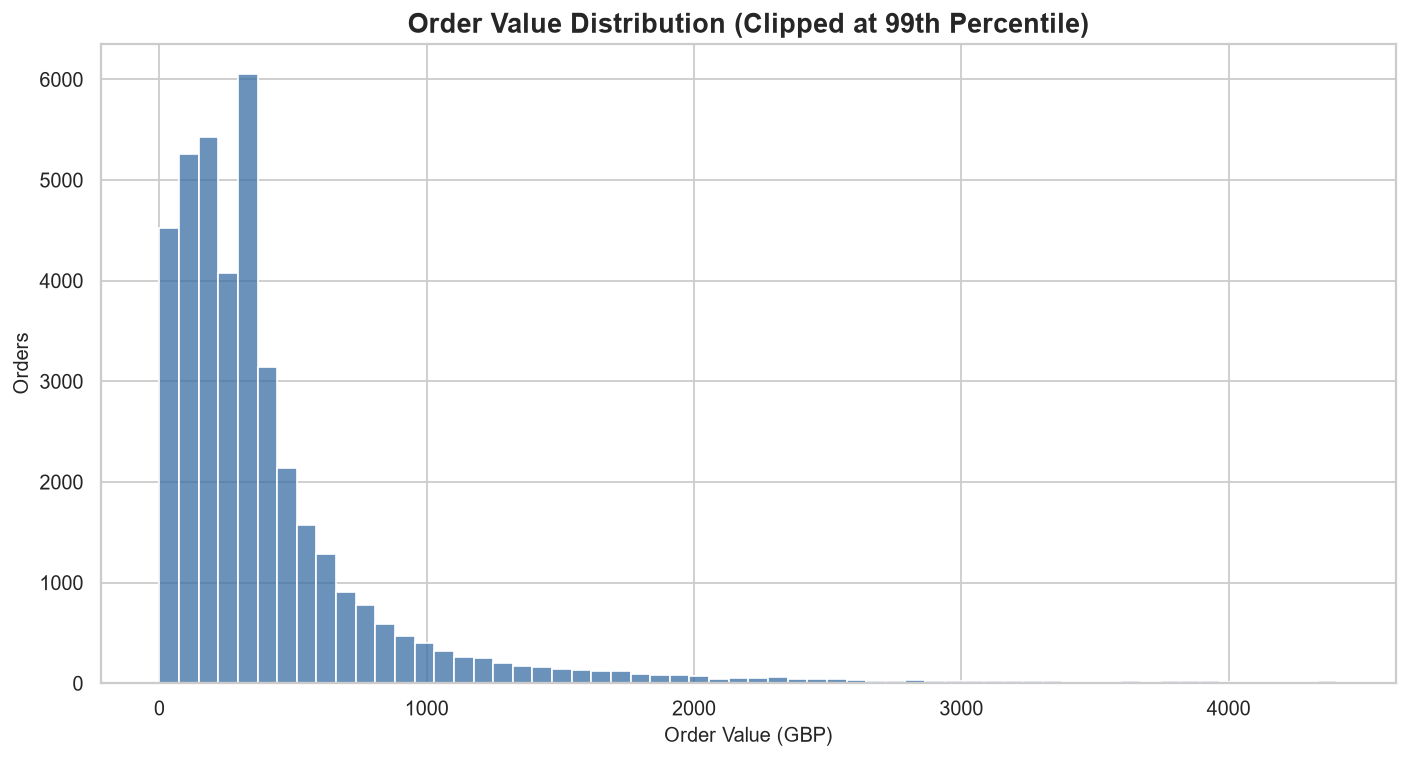

In [6]:
for chart in [
    "images/eda/01_monthly_revenue.png",
    "images/eda/04_top_countries_revenue.png",
    "images/eda/05_top_products_revenue.png",
    "images/eda/08_order_value_distribution.png",
]:
    display(Image(filename=str(PROJECT_ROOT / chart), width=820))

## Business Insights

- Confirmed completed-sales revenue is GBP 20.48 million across 40,077 orders; the United Kingdom contributes about 85% of revenue.
- Product and customer value are concentrated, so rankings should be interpreted with wholesale-like activity and non-product lines such as postage/manual adjustments in view.
- Anonymous transactions remain valid in aggregate sales and geographic/product EDA, but are excluded from customer analytics because they cannot be assigned to a stable customer history.
- December 2011 ends on 9 December and is explicitly marked partial; it should not be compared with full calendar months as if exposure were equal.

## Assumptions

- SQLite exports and EDA tables share the validated completed-sales definition.
- Country is taken from the transaction for order and geographic analysis.
- Monetary results are reported in GBP.

## Limitations

- Revenue is not profit: unit cost, shipping cost, and margin are unavailable.
- The observation period is historical and cannot establish current demand.
- Extreme orders are retained and flagged, not deleted, because legitimate wholesale activity is plausible.

## Next Steps

- Pair revenue with cost data before making profitability decisions.
- Track complete-month trends separately from partial refresh periods.
- Investigate concentrated products and customers with operational context.